In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "/Users/dougs/Annapurna Dropbox/Doug Sack/Interactive/IndieBI/sales_curve_data/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.xlsx")

# Read all files into DataFrames and add filename column
dfs = [pd.read_excel(file, skiprows=2).assign(Source=os.path.basename(file)) for file in files]




In [3]:
df = pd.concat(dfs, ignore_index=True)


In [4]:
df.head()

,Date,product,Cumulative Selected Measure,Source
0,2018-12-07,Ashen,2290,epic_units.xlsx
1,2018-12-08,Ashen,4713,epic_units.xlsx
2,2018-12-09,Ashen,7038,epic_units.xlsx
3,2018-12-10,Ashen,8702,epic_units.xlsx
4,2018-12-11,Ashen,10125,epic_units.xlsx


In [5]:
df.Source.unique()

array(['epic_units.xlsx', 'nintendo_units.xlsx', 'steam_units.xlsx',
       'PS_units.xlsx'], dtype=object)

In [6]:
release_dict = {'The Lost Wild': '2025-12-31',
 'Wattam': '2019-12-17',
 'Storyteller: Devilish Update': '2023-09-26',
 'The Artful Escape': '2021-09-09',
 'Annapurna Interactive Deluxe Limited Edition Collection': '2023-12-22',
 'Annapurna Interactive: Ultimate Collection': '2020-12-08',
 'Annapurna Interactive Deluxe Limited Edition': '2020-12-15',
 'I Am Dead': '2020-10-08',
 'Outer Wilds: Archaeologist Edition': '2021-09-28',
 'The Pathless': '2020-11-12',
 'If Found...': '2020-05-19',
 'Telling Lies': '2019-08-23',
 'A Memoir Blue': '2022-03-24',
 'Stray': '2022-07-19',
 'Last Stop': '2021-07-22',
 'To a T': '2025-05-28',
 'Mundaun': '2021-03-16',
 'Solar Ash': '2021-12-02',
 'What Remains of Edith Finch': '2017-04-24',
 'Sayonara Wild Hearts': '2019-9-19',
 'Lushfoil Photography Sim': '2025-04-15',
 'Storyteller': '2023-03-23',
 'Gorogoa': '2017-12-13',
 'Wanderstop': '2025-03-11',
 'Journey': '2012-03-13',
 'Mixtape': '2025-12-31',
 'Open Roads': '2024-03-28',
 'Neon White': '2022-06-16',
 'Flower': '2009-02-12',
 'Twelve Minutes': '2021-08-19',
 'Outer Wilds: Echoes of the Eye': '2021-09-28',
 'Flock': '2024-07-16',
 'Maquette': '2021-03-02',
 'Cocoon': '2023-09-29',
 'Gone Home': '2013-08-15',
 'Outer Wilds': '2019-05-28',
 'Ashen: Nightstorm Isle': '2019-09-06',
 'Florence': '2018-02-13',
 'Thirsty Suitors': '2023-11-02',
 'Lorelei and the Laser Eyes': '2024-05-16',
 'Donut County': '2018-08-28',
 'Skin Deep': '2025-04-30',
 'Wheel World': '2025-06-30',
 'Hohokum': '2014-08-12',
 'Ashen: Definitive Edition': '2019-11-18',
 'Morsels': '2025-12-31',
 'Kentucky Route Zero: TV Edition': '2020-01-28',
 'The Unfinished Swan': '2012-10-23',
 'Hindsight': '2022-08-04',
 'Ashen': '2018-12-07'}

In [7]:
df_combined = df.query("Source =='PS_units.xlsx'")
#df_combined['release_date'] = df_combined['product'].map(release_dict)

In [8]:
df_combined

,Date,product,Cumulative Selected Measure,Source
116443,2017-03-14,What Remains of Edith Finch,165,PS_units.xlsx
116444,2017-03-15,What Remains of Edith Finch,438,PS_units.xlsx
116445,2017-03-16,What Remains of Edith Finch,614,PS_units.xlsx
116446,2017-03-17,What Remains of Edith Finch,726,PS_units.xlsx
116447,2017-03-18,What Remains of Edith Finch,871,PS_units.xlsx
...,...,...,...,...
156512,2025-03-17,Thirsty Suitors,3761,PS_units.xlsx
156513,2025-03-17,Twelve Minutes,67452,PS_units.xlsx
156514,2025-03-17,Wanderstop,5959,PS_units.xlsx
156515,2025-03-17,Wattam,46062,PS_units.xlsx


In [9]:
df_combined['release_date'] = pd.to_datetime(df_combined['Date'])

In [10]:
df_combined['release_date'] = df_combined.groupby('product')['release_date'].transform('min')

In [11]:
df_combined["DAR"] = (df_combined["Date"] - df_combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df_combined["Weeks_from_Release"] = (df_combined["DAR"] // 30) + 1  # Week 1 starts at 0-7 days

df_combined = df_combined.query("0 <= Weeks_from_Release <=12")

df_combined = df_combined.query("'1/1/2015' <= release_date <='1/1/2025'")

df_combined = df_combined.groupby(["product", "Weeks_from_Release"], as_index=False)["Cumulative Selected Measure"].sum()

In [12]:
title_exclusion = [
'Stray','Outer Wilds'
    

]

In [13]:
df_combined['product'].unique()

array(['A Memoir Blue', 'Ashen', 'Ashen - Nightstorm Isle DLC', 'Cocoon',
       'Donut County', 'Flock', 'Gorogoa', 'Hindsight', 'I Am Dead',
       'Kentucky Route Zero: TV Edition', 'Last Stop',
       'Lorelei and the Laser Eyes', 'Maquette', 'Mundaun', 'Neon White',
       'Open Roads', 'Outer Wilds',
       'Outer Wilds - Archaeologist Edition BUNDLE',
       'Outer Wilds - Echoes of the Eye DLC', 'Sayonara Wild Hearts',
       'Solar Ash', 'Stray', 'Telling Lies', 'The Artful Escape',
       'The Pathless', 'Thirsty Suitors', 'Twelve Minutes', 'Wattam',
       'What Remains of Edith Finch'], dtype=object)

In [14]:
df_combined

,product,Weeks_from_Release,Cumulative Selected Measure
0,A Memoir Blue,1,33571
1,A Memoir Blue,2,58760
2,A Memoir Blue,3,86688
3,A Memoir Blue,4,98566
4,A Memoir Blue,5,109498
...,...,...,...
332,What Remains of Edith Finch,8,1819584
333,What Remains of Edith Finch,9,1944759
334,What Remains of Edith Finch,10,2217810
335,What Remains of Edith Finch,11,2852331


In [15]:
df_combined = df_combined.query("product !=@title_exclusion")

In [16]:
#pd.set_option("display.max_rows", None)


df_combined["CUME_total"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].transform("max")
df_combined["prop_of_total"] = df_combined["Cumulative Selected Measure"] / df_combined["CUME_total"]
df_combined["daily_delta"] = df_combined.groupby(["product"])["Cumulative Selected Measure"].pct_change().fillna(0)
df_combined.query("product=='Maquette'")


,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta
133,Maquette,1,47564,280653,0.169476,0.000000
134,Maquette,2,98342,280653,0.350404,1.067572
135,Maquette,3,132088,280653,0.470645,0.343149
136,Maquette,4,150093,280653,0.534799,0.136311
137,Maquette,5,164389,280653,0.585738,0.095248
138,Maquette,6,186240,280653,0.663595,0.132923
139,Maquette,7,198085,280653,0.705800,0.063601
140,Maquette,8,209410,280653,0.746153,0.057172
141,Maquette,9,222254,280653,0.791917,0.061334
142,Maquette,10,245260,280653,0.873891,0.103512


In [17]:
df_combined.query("Weeks_from_Release==1")


,product,Weeks_from_Release,Cumulative Selected Measure,CUME_total,prop_of_total,daily_delta
0,A Memoir Blue,1,33571,181904,0.184553,0.0
12,Ashen,1,135553,820247,0.165259,0.0
24,Ashen - Nightstorm Isle DLC,1,28996,200224,0.144818,0.0
36,Cocoon,1,196678,1359167,0.144705,0.0
48,Donut County,1,100231,1321344,0.075855,0.0
60,Flock,1,25850,55740,0.463760,0.0
69,Gorogoa,1,12826,253778,0.050540,0.0
81,Hindsight,1,4526,36063,0.125503,0.0
93,I Am Dead,1,18892,96478,0.195817,0.0
105,Kentucky Route Zero: TV Edition,1,117318,651336,0.180119,0.0


In [18]:
platform_df = df_combined.groupby("Weeks_from_Release")[['daily_delta']].mean()
platform_df['platform'] = 'PS'

In [19]:
platform_df

,daily_delta,platform
Weeks_from_Release,,
1,0.000000,PS
2,1.790429,PS
3,0.402895,PS
4,0.174873,PS
5,0.155128,PS
6,0.098915,PS
7,0.078483,PS
8,0.061522,PS
9,0.031781,PS


In [20]:
stop

NameError: name 'stop' is not defined

In [ ]:
platform_df.to_csv("units/PS_units_average.csv")

In [ ]:
stop

In [21]:
### Fit the Curve to a model and use this to predict



# Define folder path
folder_path = "/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/"

# Get all .xlsx files in the folder
files = glob.glob(f"{folder_path}/*.csv")

# Read all files into DataFrames and add filename column
dfs = [pd.read_csv(file).assign(Source=os.path.basename(file)) for file in files]




In [22]:
files

['/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/epic_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/PS_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/nintendo_units_average.csv',
 '/Users/dougs/Documents/GitHub/IndieBI-Sales-EDA/units/steam_units_average.csv']

In [23]:
av_df = pd.concat(dfs, ignore_index=True)


In [24]:
platforms = av_df.pivot_table(columns='platform', index='Weeks_from_Release', values='daily_delta').reset_index()

In [25]:
platforms.to_clipboard()

In [26]:
platforms.columns[1:]

Index(['PS', 'epic', 'nintendo', 'steam'], dtype='object', name='platform')

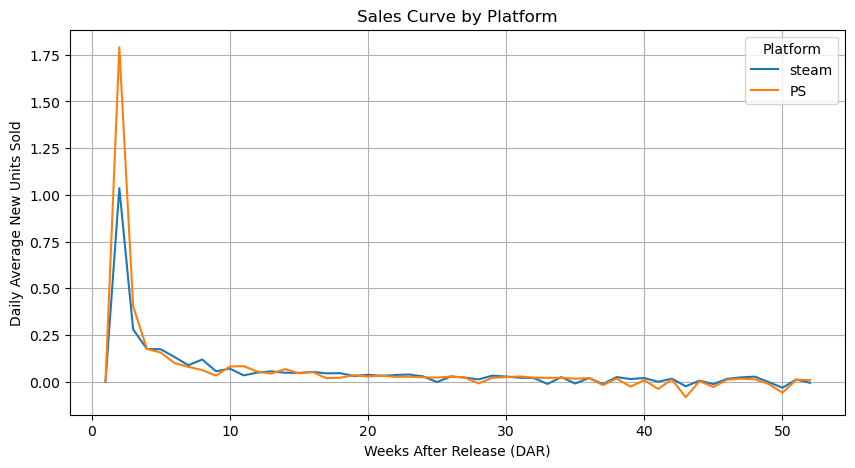

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility

# Loop through unique platforms and plot each separately
for platform in ['steam', 'PS']:
    pdf = av_df.query("platform == @platform")
    sns.lineplot(data=pdf, x='Weeks_from_Release', y='daily_delta', label=platform)

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.grid(True)  # Add grid for readability

plt.show()

In [28]:
platforms.query("Weeks_from_Release <=12")

platform,Weeks_from_Release,PS,epic,nintendo,steam
0,1,0.000000,0.000000,0.000000,0.000000
1,2,1.790429,1.912999,0.764520,1.036082
2,3,0.402895,0.314070,0.278488,0.279489
3,4,0.174873,0.489742,0.168990,0.174618
4,5,0.155128,0.421841,0.135624,0.172837
5,6,0.098915,0.161280,0.127583,0.131473
6,7,0.078483,0.096206,0.125476,0.087160
7,8,0.061522,0.133661,0.083962,0.118133
8,9,0.031781,0.050247,0.062124,0.054990
9,10,0.080426,0.062037,0.057157,0.069369


In [29]:
starting_val = 31_200

In [30]:
current_week  = 1

In [31]:
platforms.loc[current_week-1,'steam_projected'] = starting_val

In [32]:
platforms.loc[current_week-1,'steam_projected'] = starting_val

In [33]:
# Apply cumulative product starting from the specified index
platforms.loc[current_week:, 'steam_projected'] = (
    starting_val * (1 + platforms.loc[current_week:, 'steam']).cumprod()
)

In [34]:
platforms['steam_projected'] = platforms['steam_projected'].fillna(starting_val)
platforms['steam_projected'] = platforms['steam_projected'].astype(int)

In [35]:
platforms

platform,Weeks_from_Release,PS,epic,nintendo,steam,steam_projected
0,1,0.000000,0.000000,0.000000,0.000000,31200
1,2,1.790429,1.912999,0.764520,1.036082,63525
2,3,0.402895,0.314070,0.278488,0.279489,81280
3,4,0.174873,0.489742,0.168990,0.174618,95473
4,5,0.155128,0.421841,0.135624,0.172837,111975
5,6,0.098915,0.161280,0.127583,0.131473,126696
6,7,0.078483,0.096206,0.125476,0.087160,137739
7,8,0.061522,0.133661,0.083962,0.118133,154011
8,9,0.031781,0.050247,0.062124,0.054990,162480
9,10,0.080426,0.062037,0.057157,0.069369,173751


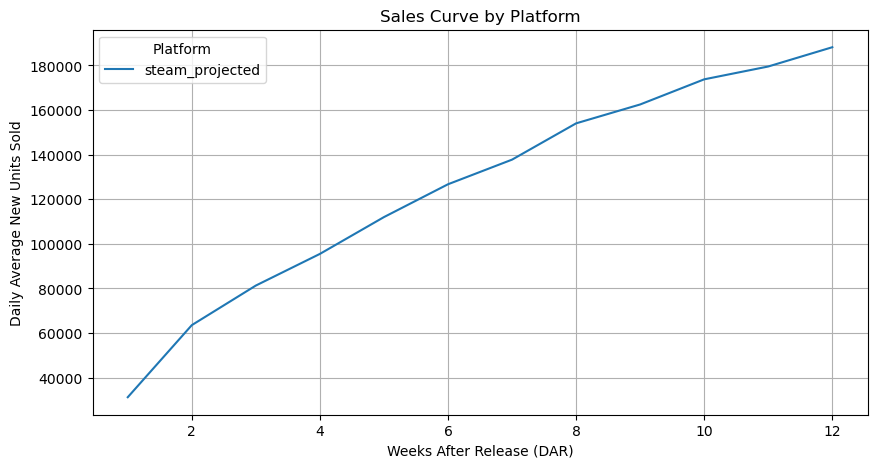

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # Adjust figure size for better visibility


sns.lineplot(data=platforms.query("Weeks_from_Release <=12"), x='Weeks_from_Release', y='steam_projected', label='steam_projected')

# Improve aesthetics
plt.xlabel("Weeks After Release (DAR)")
plt.ylabel("Daily Average New Units Sold")
plt.title("Sales Curve by Platform")
plt.legend(title="Platform", loc="best")  # Set legend title
plt.grid(True)  # Add grid for readability

plt.show()